In [1]:
import os
import cv2
import numpy as np
import shutil
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [2]:
# Función para cargar y etiquetar imágenes
from typing import Any


def load_and_label_data(folder, output_folder):
    images = []
    labels = []
    for label, class_folder in enumerate[Any](os.listdir(folder)):
        class_path = os.path.join(folder, class_folder)
        output_class_path = os.path.join(output_folder, class_folder)
        if not os.path.exists(output_class_path):
            os.makedirs(output_class_path)
        print(f"Cargando imágenes de la clase '{class_folder}'...")
        for i, filename in enumerate(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename))

            if img is None:
                print(f"  [!] Error: No se pudo leer '{filename}'. Saltando...")
                continue



            if i < 5:
                # Mostrar imágenes originales y redimensionadas
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                axes[0].set_title('Imagen original')

            img_resized = cv2.resize(img, (500, 500))  # Redimensionar según sea necesario
            print(f"Procesando imagen: {filename} (Clase: {class_folder})")

            if i < 5:
                # Mostrar imágenes redimensionadas
                axes[1].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
                axes[1].set_title('Imagen redimensionada')
                plt.show()

            images.append(img_resized)
            labels.append(label)  # Usar el índice de la clase como etiqueta

            # Guardar imágenes redimensionadas en la nueva carpeta
            output_filename = os.path.join(output_class_path, filename)
            cv2.imwrite(output_filename, img_resized)

    print("Carga y etiquetado completados.")
    return np.array(images), np.array(labels)

Cargando imágenes de la clase 'Gato'...
Procesando imagen: 1.jpg (Clase: Gato)


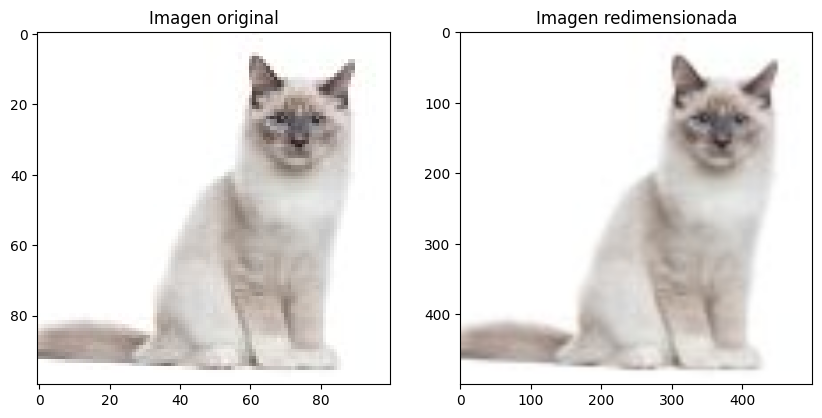

Procesando imagen: 10.png (Clase: Gato)


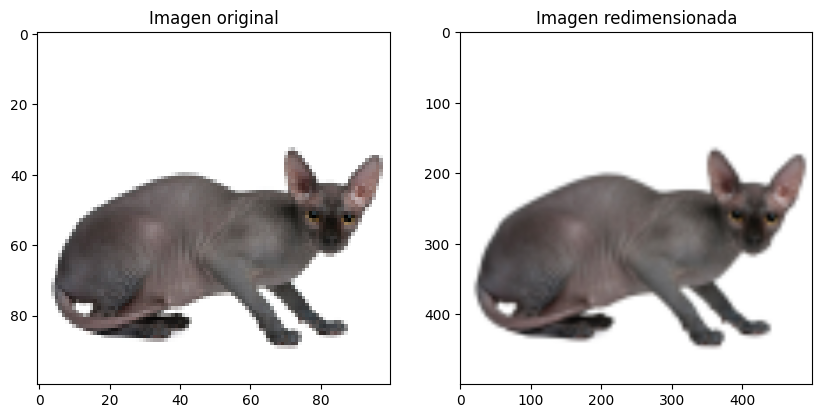

Procesando imagen: 11.jpg (Clase: Gato)


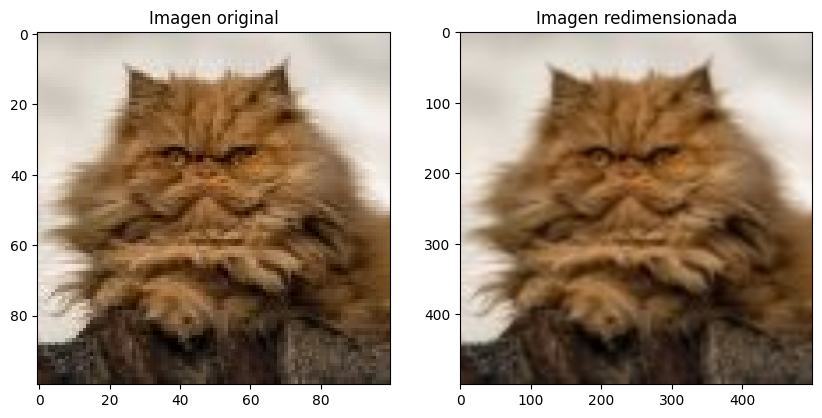

Procesando imagen: 12.jpg (Clase: Gato)


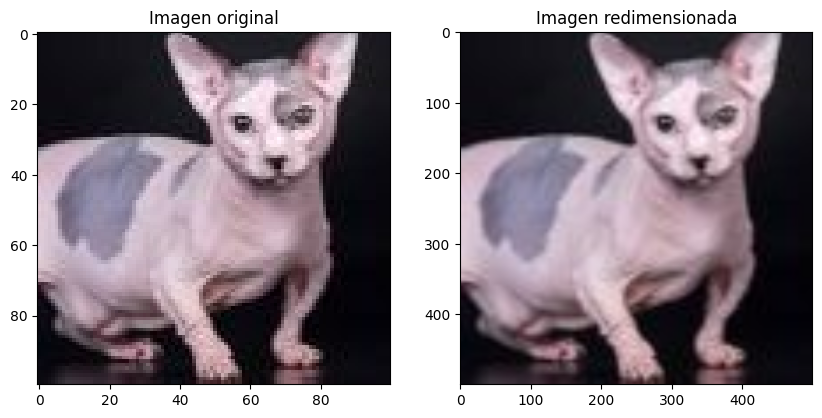

Procesando imagen: 13.jpg (Clase: Gato)


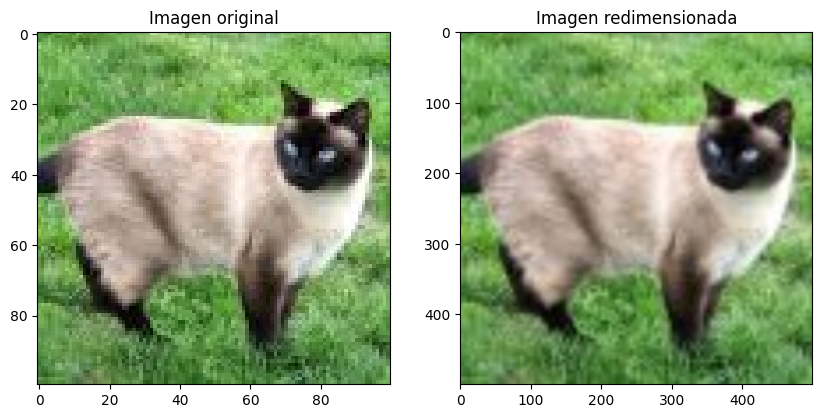

Procesando imagen: 14.jpg (Clase: Gato)
Procesando imagen: 15.jpg (Clase: Gato)
Procesando imagen: 16.jpg (Clase: Gato)
Procesando imagen: 17.jpg (Clase: Gato)
Procesando imagen: 18.jpg (Clase: Gato)
Procesando imagen: 19.jpg (Clase: Gato)
Procesando imagen: 2.jpg (Clase: Gato)
Procesando imagen: 20.jpg (Clase: Gato)
Procesando imagen: 21.jpg (Clase: Gato)
Procesando imagen: 22.jpg (Clase: Gato)
Procesando imagen: 23.jpg (Clase: Gato)
Procesando imagen: 24.png (Clase: Gato)
Procesando imagen: 25.jpg (Clase: Gato)
Procesando imagen: 26.png (Clase: Gato)
Procesando imagen: 27.png (Clase: Gato)
Procesando imagen: 28.png (Clase: Gato)
Procesando imagen: 29.jpg (Clase: Gato)
Procesando imagen: 3.jpg (Clase: Gato)
Procesando imagen: 30.png (Clase: Gato)
Procesando imagen: 31.jpg (Clase: Gato)
Procesando imagen: 32.jpg (Clase: Gato)
Procesando imagen: 33.jpg (Clase: Gato)
Procesando imagen: 34.jpeg (Clase: Gato)
Procesando imagen: 35.jpg (Clase: Gato)
Procesando imagen: 36.jpg (Clase: Gato)
P

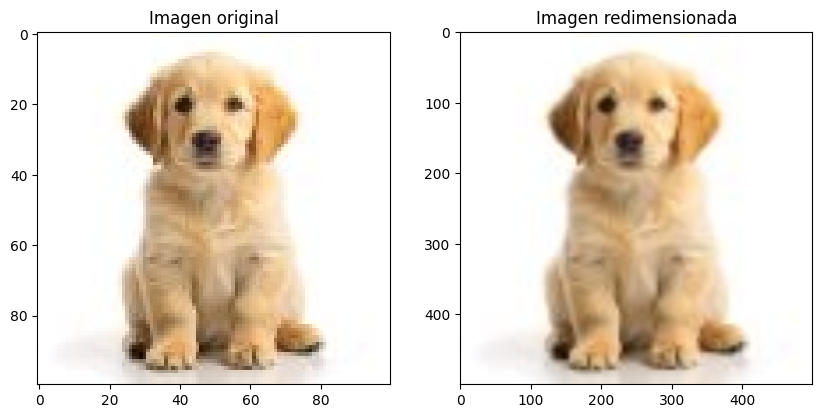

Procesando imagen: 10.jpg (Clase: Perro)


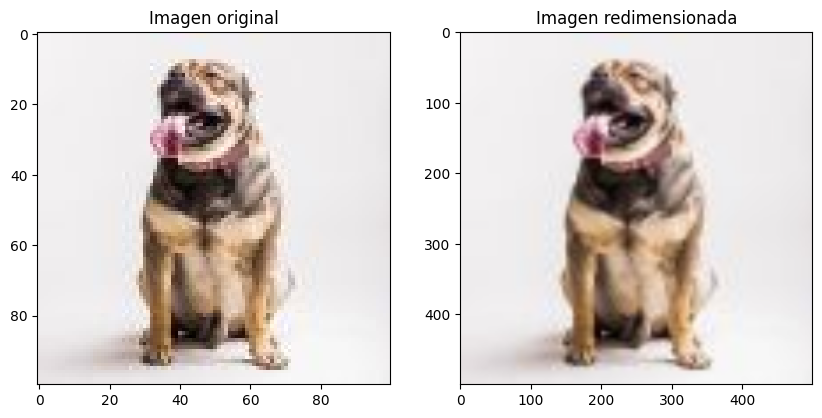

Procesando imagen: 11.jpg (Clase: Perro)


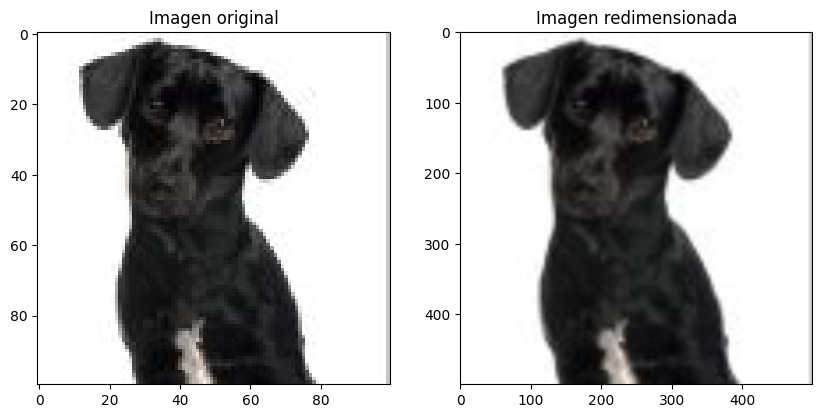

Procesando imagen: 12.jpg (Clase: Perro)


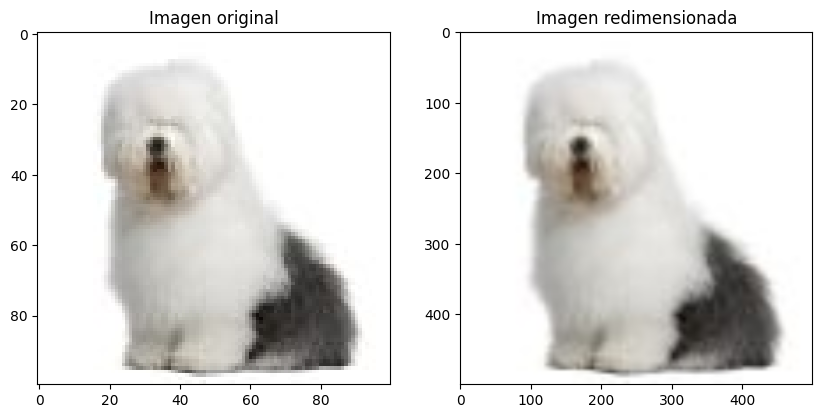

Procesando imagen: 13.jpg (Clase: Perro)


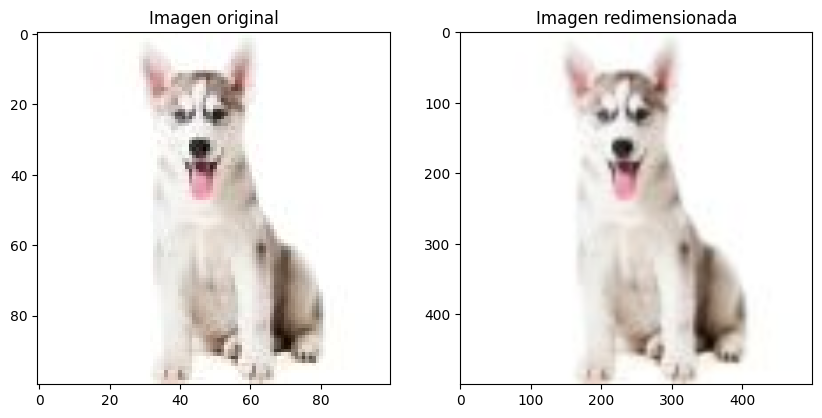

Procesando imagen: 14.jpg (Clase: Perro)
Procesando imagen: 15.jpg (Clase: Perro)
Procesando imagen: 16.jpg (Clase: Perro)
Procesando imagen: 17.jpg (Clase: Perro)
Procesando imagen: 18.jpg (Clase: Perro)
Procesando imagen: 19.jpg (Clase: Perro)
Procesando imagen: 2.jpg (Clase: Perro)
Procesando imagen: 20.jpg (Clase: Perro)
Procesando imagen: 21.jpg (Clase: Perro)
  [!] Error: No se pudo leer '22.avif'. Saltando...
Procesando imagen: 22.jpg (Clase: Perro)
Procesando imagen: 23.jpg (Clase: Perro)
Procesando imagen: 24.jpg (Clase: Perro)
Procesando imagen: 25.jpg (Clase: Perro)
Procesando imagen: 26.jpg (Clase: Perro)
Procesando imagen: 27.jpg (Clase: Perro)
Procesando imagen: 28.jpg (Clase: Perro)
Procesando imagen: 29.jpg (Clase: Perro)
Procesando imagen: 3.jpg (Clase: Perro)
Procesando imagen: 30.jpg (Clase: Perro)
  [!] Error: No se pudo leer '31.avif'. Saltando...
Procesando imagen: 31.jpg (Clase: Perro)
Procesando imagen: 32.jpg (Clase: Perro)
Procesando imagen: 33.png (Clase: Per

In [3]:
ruta_path = './DatasetPerrosGatos'
# Directorio que contiene las carpetas de perros y gatos
data_folder = ruta_path

# Carpeta para guardar las imágenes redimensionadas
output_folder = './DatasetRedimensionado'

# Cargar y etiquetar las imágenes y guardar las imágenes redimensionadas
X, y = load_and_label_data(data_folder, output_folder)

ruta_save_dataset='datos_etiquetados_21_02_26.pickle'
# Guardar los datos etiquetados
with open(ruta_save_dataset, 'wb') as handle:
    pickle.dump((X, y), handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Datos etiquetados guardados correctamente.")

# Dividir datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ahora X_train, X_test, y_train, y_test están listos para ser utilizados en el entrenamiento de tu modelo

In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Normalizar los datos de las imágenes
X = X.astype('float32') / 255.0

# Convertir etiquetas a one-hot encoding
y = to_categorical(y, 2)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Aplanar las imágenes para el MLP
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat = X_test.reshape((X_test.shape[0], -1))

# Construir el modelo MLP
model_mlp = Sequential([
Flatten(input_shape=(500*500*3,)),
Dense(512, activation='relu'),
Dense(2, activation='softmax')
])

model_mlp.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

# Entrenar el modelo
history_mlp = model_mlp.fit(X_train_flat, y_train, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

c:\Users\estudiante\Desktop\IA innovador\C_PERROS_GATOS\_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 265s 167s/step - accuracy: 0.4815 - loss: 1289.5312 - val_accuracy: 0.5714 - val_loss: 957.6594
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 342s 172s/step - accuracy: 0.5000 - loss: 946.6313 - val_accuracy: 0.4286 - val_loss: 956.3006
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 335s 181s/step - accuracy: 0.4630 - loss: 856.1026 - val_accuracy: 0.4286 - val_loss: 473.8212
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 345s 188s/step - accuracy: 0.4815 - loss: 277.0644 - val_accuracy: 0.5714 - val_loss: 359.9838
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 382s 199s/step - accuracy: 0.5370 - loss: 467.5125 - val_accuracy: 0.5714 - val_loss: 549.8668
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 339s 195s/step - accuracy: 0.5370 - loss: 589.9814 - val_accuracy: 0.5714 - val_loss: 297.7139
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 305s 170s/step - accuracy: 0.5556 - loss: 242.2202 - val_accuracy: 0.4286 - val_loss: 139.6123
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 309s 159s/step - accuracy: 0.4630 - loss: 217.

In [4]:

# Función para aplicar aumentos de datos a una imagen y guardarlas en el mismo directorio
def apply_augmentations_and_save(img, output_folder, filename):
    # Guardar imagen original
    cv2.imwrite(os.path.join(output_folder, f"original_{filename}"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    # Rotar 90 grados y guardar
    rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    cv2.imwrite(os.path.join(output_folder, f"rotated_90_{filename}"), cv2.cvtColor(rotated_90, cv2.COLOR_RGB2BGR))

    # Rotar 180 grados y guardar
    rotated_180 = cv2.rotate(img, cv2.ROTATE_180)
    cv2.imwrite(os.path.join(output_folder, f"rotated_180_{filename}"), cv2.cvtColor(rotated_180, cv2.COLOR_RGB2BGR))

    # Invertir y guardar
    #inverted = cv2.flip(img, -1)
    #cv2.imwrite(os.path.join(output_folder, f"inverted_{filename}"), cv2.cvtColor(inverted, cv2.COLOR_RGB2BGR))

    # Aumento de brillo y guardar
    brightened = cv2.convertScaleAbs(img, alpha=1.5, beta=50)
    cv2.imwrite(os.path.join(output_folder, f"brightened_{filename}"), cv2.cvtColor(brightened, cv2.COLOR_RGB2BGR))

    # Modo espejo y guardar
    mirrored = cv2.flip(img, 1)
    cv2.imwrite(os.path.join(output_folder, f"mirrored_{filename}"), cv2.cvtColor(mirrored, cv2.COLOR_RGB2BGR))

# Directorio que contiene las carpetas de perros y gatos
data_folder = './DatasetRedimensionado/'

# Carpeta para guardar las imágenes aumentadas manualmente
output_folder_manual = './DatasetRedimensionadoAumentado'

# Crear carpeta de salida si no existe
if not os.path.exists(output_folder_manual):
    os.makedirs(output_folder_manual)

# Iterar sobre las carpetas de clases
for class_folder in os.listdir(data_folder):
    class_path = os.path.join(data_folder, class_folder)
    output_class_folder = os.path.join(output_folder_manual, class_folder)
    if not os.path.exists(output_class_folder):
        os.makedirs(output_class_folder)
    # Iterar sobre las imágenes en la carpeta de clase
    for filename in os.listdir(class_path):
        img = cv2.imread(os.path.join(class_path, filename))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Aplicar aumentos de datos y guardar las imágenes aumentadas en la carpeta de clase correspondiente
        apply_augmentations_and_save(img, output_class_folder, filename)

print("Aumento de datos manual completado.")

Aumento de datos manual completado.


In [5]:
# Función para cargar y etiquetar imágenes
from typing import Any


def load_and_label_data_aumentado(folder):
    images = []
    labels = []
    for label, class_folder in enumerate[Any](os.listdir(folder)):
        class_path = os.path.join(folder, class_folder)
                  
        
        for i, filename in enumerate(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename))

            if img is None:
                print(f"  [!] Error: No se pudo leer '{filename}'. Saltando...")
                continue

            images.append(img)
            labels.append(label)  # Usar el índice de la clase como etiqueta

    print("Carga y etiquetado completados.")
    return np.array(images), np.array(labels)

In [6]:
data_aumentado = './DatasetRedimensionadoAumentado'
# Cargar y etiquetar las imágenes y guardar las imágenes redimensionadas
X_a, y_a = load_and_label_data_aumentado(data_aumentado)

ruta_save_dataset='datos_etiquetados_21_02_26_aumentado.pickle'
# Guardar los datos etiquetados
with open(ruta_save_dataset, 'wb') as handle:
    pickle.dump((X_a, y_a), handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Datos etiquetados guardados correctamente.")

Carga y etiquetado completados.
Datos etiquetados guardados correctamente.


In [7]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Normalizar los datos de las imágenes
X_a = X_a.astype('float32') / 255.0

# Convertir etiquetas a one-hot encoding
y_a = to_categorical(y_a, 2)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.2, random_state=42)


# Aplanar las imágenes para el MLP
X_train_flat_a = X_train_a.reshape((X_train_a.shape[0], -1))
X_test_flat_a = X_test_a.reshape((X_test_a.shape[0], -1))

# Construir el modelo MLP
model_mlp = Sequential([
Flatten(input_shape=(500*500*3,)),
Dense(512, activation='relu'),
Dense(2, activation='softmax')
])

model_mlp.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

# Entrenar el modelo
history_mlp = model_mlp.fit(X_train_flat_a, y_train_a, epochs=10, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

c:\Users\estudiante\Desktop\IA innovador\C_PERROS_GATOS\_env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1032s 117s/step - accuracy: 0.5345 - loss: 662.3243 - val_accuracy: 0.4783 - val_loss: 92.4659
Epoch 2/10
3/9 ━━━━━━━━━━━━━━━━━━━━ 11:23 114s/step - accuracy: 0.5486 - loss: 76.2888


KeyboardInterrupt

